# Tutorial: Implementing BO through Scikit-Learn Gaussian Process

## Gaussian Process Surrogate

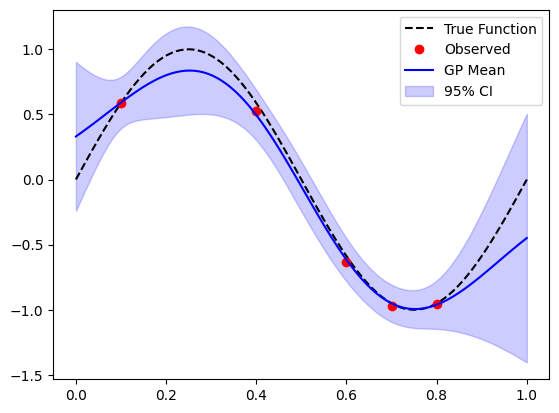

In [6]:
# type: ignore

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel

# Generate synthetic training data
X_train = np.array([0.1, 0.4, 0.6, 0.7, 0.8]).reshape(-1, 1)
y_train = np.sin(2 * np.pi * X_train).ravel() + np.random.normal(0, 0.1, X_train.shape[0])

# Define kernel: constant * RBF + Matern (as an example)
kernel = ConstantKernel(1.0) * RBF(length_scale=0.2) + Matern(length_scale=0.2, nu=1.5)

# Instantiate GP regressor
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1**2, n_restarts_optimizer=10)

# Fit to data
gp.fit(X_train, y_train)

# Predict at new points
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_pred, y_std = gp.predict(X_test, return_std=True)

# Plot results (optional)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(X_test, np.sin(2 * np.pi * X_test), 'k--', label='True Function')
plt.plot(X_train, y_train, 'ro', label='Observed')
plt.plot(X_test, y_pred, 'b-', label='GP Mean')
plt.fill_between(X_test.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, color='blue', alpha=0.2, label='95% CI')
plt.legend()
plt.show()

## Acquisition Functions

In [7]:
from scipy.stats import norm

def acq_ucb(x, gp, beta=2.0):
    """Upper Confidence Bound acquisition."""
    mu, std = gp.predict(x, return_std=True)
    return mu + beta * std

def acq_ei(x, gp, y_best, xi=0.0):
    """Expected Improvement acquisition."""
    mu, std = gp.predict(x, return_std=True)
    std = std.reshape(-1)
    mu = mu.reshape(-1)
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / std
        ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
        ei[std == 0.0] = 0.0
    return ei

def acq_pi(x, gp, y_best, xi=0.0):
    """Probability of Improvement acquisition."""
    mu, std = gp.predict(x, return_std=True)
    std = std.reshape(-1)
    mu = mu.reshape(-1)
    with np.errstate(divide='warn'):
        Z = (mu - y_best - xi) / std
        pi = norm.cdf(Z)
        pi[std == 0.0] = 0.0
    return pi

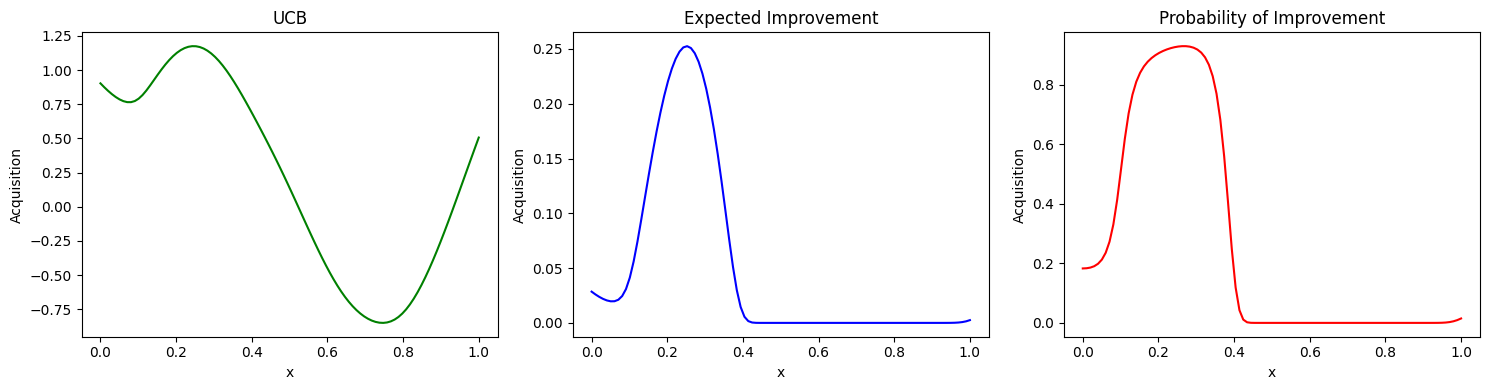

In [8]:
# Plot acquisition functions

y_best = np.max(y_train)

acq_ucb_vals = acq_ucb(X_test, gp)
acq_ei_vals = acq_ei(X_test, gp, y_best)
acq_pi_vals = acq_pi(X_test, gp, y_best)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(X_test, acq_ucb_vals, 'g-', label='UCB')
axes[0].set_title('UCB')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Acquisition')

axes[1].plot(X_test, acq_ei_vals, 'b-', label='EI')
axes[1].set_title('Expected Improvement')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Acquisition')

axes[2].plot(X_test, acq_pi_vals, 'r-', label='PI')
axes[2].set_title('Probability of Improvement')
axes[2].set_xlabel('x')
axes[2].set_ylabel('Acquisition')

plt.tight_layout()
plt.show()